#**End-to-End Machine Learning Project: Airbnb Price Prediction**

###**Objective**
#####Build a complete machine learning workflow for Airbnb price prediction and make the final model usable through a simple web application.

##**Task 1 - Data Analysis and Preparation**

● Analyze the Airbnb dataset and perform suitable cleaning, preprocessing, transformation, feature
engineering, and feature selection. Handle missing values and outliers appropriately.

● Summarize the important data patterns, preprocessing decisions, and features that may influence Airbnb
prices.

Original Dataset Shape: (48895, 16)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews           

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



--- Statistical Summary ---


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000



--- Missing Values ---


,Missing Values,Missing Percentage
name,16,0.03
host_name,21,0.04
last_review,10052,20.56
reviews_per_month,10052,20.56



--- Duplicate Records ---
Number of duplicate rows: 0

--- Invalid Price Values ---
Listings with price <= 0: 11

--- Price Outlier Analysis ---
Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0
Number of price outliers: 2972


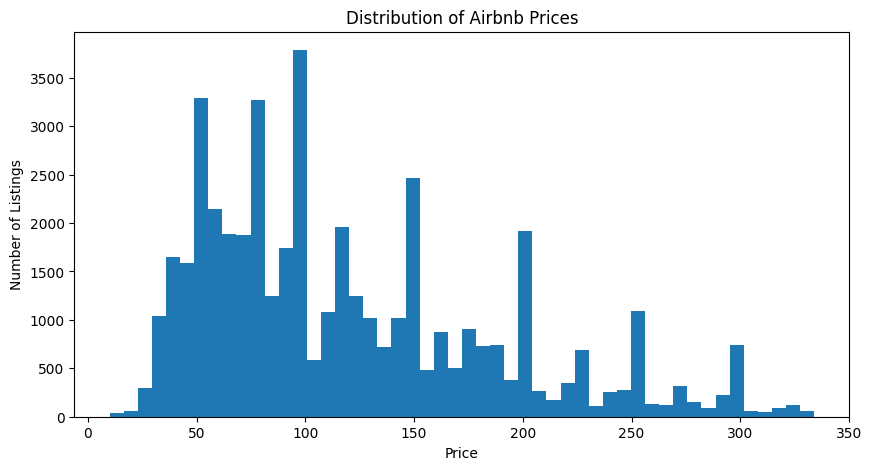

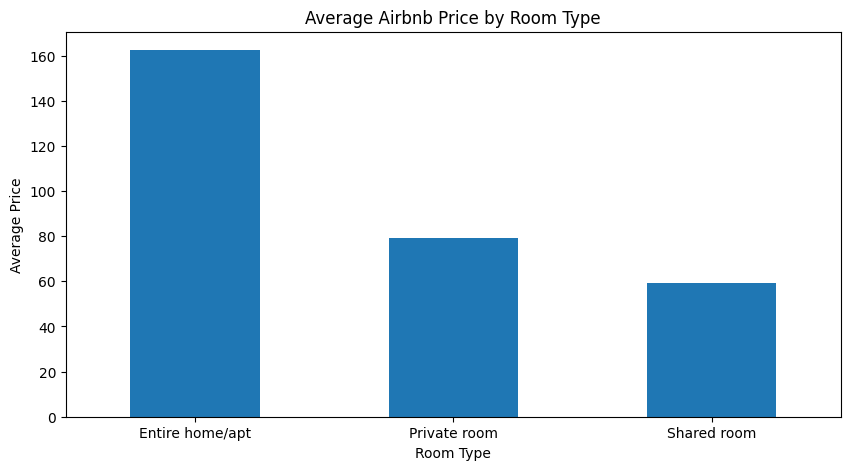

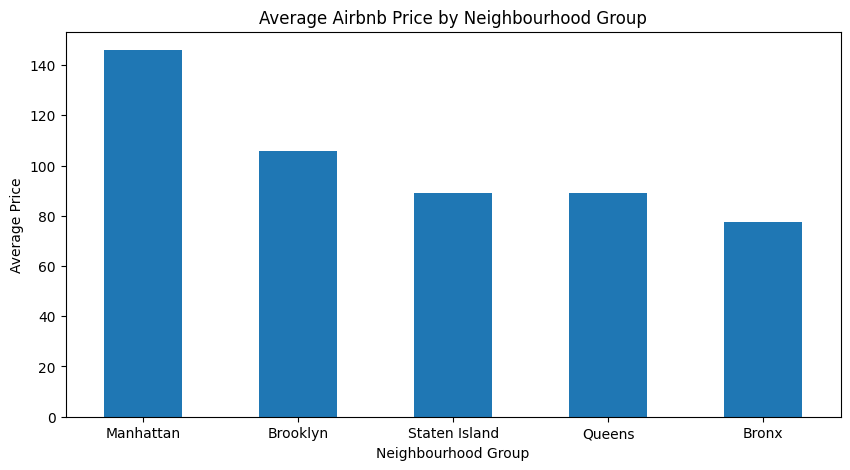


--- Correlation with Price ---


,Correlation with Price
price,1.000000
calculated_host_listings_count,0.174409
host_activity,0.078336
latitude,0.068747
availability_365,0.066670
minimum_nights,0.031476
number_of_reviews,-0.027606
reviews_per_month,-0.039521
longitude,-0.306968



--- Selected Features ---
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'host_activity']

Target Variable: price

Final Dataset Shape: (45912, 15)
Feature Dataset Shape: (45912, 11)
Target Dataset Shape: (45912,)

--- Final Missing Value Check ---
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
host_activity                     0
dtype: int64

TASK 1 SUMMARY
✓ Dataset loaded and analyzed
✓ Duplicate records checked and removed
✓ Missing values handled
✓ Invalid price values removed
✓ Price outliers handled using IQR method
✓ Price tra

In [ ]:
# ============================================================
# TASK 1 — DATA ANALYSIS AND PREPARATION
# Airbnb Price Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("AB_NYC_2019.csv")

print("Original Dataset Shape:", df.shape)

# ------------------------------------------------------------
# 2. Basic Dataset Analysis
# ------------------------------------------------------------

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percent.round(2)
})

display(missing_summary[missing_summary["Missing Values"] > 0])

# ------------------------------------------------------------
# 3. Duplicate Records
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print("\n--- Duplicate Records ---")
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()

# ------------------------------------------------------------
# 4. Handle Missing Values
# ------------------------------------------------------------

# These columns are not useful for numerical price prediction
# and contain missing/unstructured information.
columns_to_remove = [
    "name",
    "host_name",
    "last_review"
]

df = df.drop(columns=columns_to_remove)

# reviews_per_month contains missing values.
# Missing reviews per month are replaced with the median.
df["reviews_per_month"] = df["reviews_per_month"].fillna(
    df["reviews_per_month"].median()
)

# ------------------------------------------------------------
# 5. Handle Invalid Price Values
# ------------------------------------------------------------

invalid_price_count = (df["price"] <= 0).sum()

print("\n--- Invalid Price Values ---")
print("Listings with price <= 0:", invalid_price_count)

df = df[df["price"] > 0].copy()

# ------------------------------------------------------------
# 6. Outlier Analysis and Handling
# ------------------------------------------------------------

# Price contains extreme values which can strongly affect
# regression models. The IQR method is used to identify
# extreme price outliers.

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("\n--- Price Outlier Analysis ---")
print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Number of price outliers:", len(outliers))

# Keep prices within the IQR-based upper limit.
df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

# ------------------------------------------------------------
# 7. Feature Engineering
# ------------------------------------------------------------

# Create a simple host activity feature.
df["host_activity"] = (
    df["calculated_host_listings_count"] +
    df["number_of_reviews"]
)

# Log transformation of price helps reduce right-skewness
# for regression modeling.
df["log_price"] = np.log1p(df["price"])

# ------------------------------------------------------------
# 8. Exploratory Data Analysis
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

plt.figure(figsize=(10, 5))
df.groupby("room_type")["price"].mean().sort_values(
    ascending=False
).plot(kind="bar")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.title("Average Airbnb Price by Room Type")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10, 5))
df.groupby("neighbourhood_group")["price"].mean().sort_values(
    ascending=False
).plot(kind="bar")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.title("Average Airbnb Price by Neighbourhood Group")
plt.xticks(rotation=0)
plt.show()

# ------------------------------------------------------------
# 9. Numerical Correlation with Price
# ------------------------------------------------------------

numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude",
    "host_activity"
]

correlation = df[numeric_columns].corr()

print("\n--- Correlation with Price ---")
display(
    correlation["price"]
    .sort_values(ascending=False)
    .to_frame(name="Correlation with Price")
)

# ------------------------------------------------------------
# 10. Feature Selection
# ------------------------------------------------------------

features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "host_activity"
]

target = "price"

X = df[features]
y = df[target]

print("\n--- Selected Features ---")
print(features)

print("\nTarget Variable:", target)

print("\nFinal Dataset Shape:", df.shape)
print("Feature Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

# ------------------------------------------------------------
# 11. Final Missing Value Check
# ------------------------------------------------------------

print("\n--- Final Missing Value Check ---")
print(X.isnull().sum())

# ------------------------------------------------------------
# 12. Task 1 Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 1 SUMMARY")
print("=" * 60)

print("✓ Dataset loaded and analyzed")
print("✓ Duplicate records checked and removed")
print("✓ Missing values handled")
print("✓ Invalid price values removed")
print("✓ Price outliers handled using IQR method")
print("✓ Price transformation created using log1p")
print("✓ Host activity feature engineered")
print("✓ Exploratory analysis performed")
print("✓ Important price relationships examined")
print("✓ Relevant features selected for machine learning")
print("=" * 60)

##**Task 2 - Model Training and Evaluation**
● Train and compare suitable regression models, select the best model, perform appropriate hyperparameter tuning, and evaluate the final model using suitable regression metrics. Check for possible overfitting or underfitting and address it where required.

● Save the final preprocessing workflow and trained model so that the same pipeline can be used for new
inputs.

In [11]:
# ============================================================
# TASK 2 — MODEL TRAINING AND EVALUATION
# Airbnb Price Prediction
# ============================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. LOAD AND PREPARE DATA
# ============================================================

df = pd.read_csv("AB_NYC_2019.csv")

print("Original Dataset Shape:", df.shape)


# Remove unnecessary columns
columns_to_remove = [
    "name",
    "host_name",
    "last_review"
]

df = df.drop(columns=columns_to_remove)


# Handle missing values
df["reviews_per_month"] = df["reviews_per_month"].fillna(
    df["reviews_per_month"].median()
)


# Remove invalid prices
df = df[df["price"] > 0].copy()


# Handle price outliers using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()


# Feature engineering
df["host_activity"] = (
    df["calculated_host_listings_count"]
    + df["number_of_reviews"]
)


# ============================================================
# 2. SELECT FEATURES AND TARGET
# ============================================================

features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "host_activity"
]

X = df[features]
y = df["price"]


print("\nFinal Dataset Shape:", df.shape)
print("Features:", X.shape)
print("Target:", y.shape)


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)


# ============================================================
# 4. DEFINE FEATURES
# ============================================================

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "host_activity"
]


# ============================================================
# 5. PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# ============================================================
# 6. DEFINE REGRESSION MODELS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=10
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


# ============================================================
# 7. TRAIN AND COMPARE MODELS
# ============================================================

results = []
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    train_r2 = r2_score(
        y_train,
        train_predictions
    )

    test_r2 = r2_score(
        y_test,
        test_predictions
    )

    mae = mean_absolute_error(
        y_test,
        test_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions
        )
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": test_r2,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2
    })

    trained_models[model_name] = pipeline


# ============================================================
# 8. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.round(3)
)


# ============================================================
# 9. SELECT BEST MODEL
# ============================================================

# Lower RMSE means better prediction performance
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

best_pipeline = trained_models[best_model_name]

print("\nBest Model:", best_model_name)


# ============================================================
# 10. HYPERPARAMETER TUNING
# ============================================================

if best_model_name == "Random Forest":

    parameter_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 15,20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }

elif best_model_name == "Gradient Boosting":

    parameter_grid = {
        "model__n_estimators": [100, 150, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_split": [2, 5, 10]
    }

else:

    parameter_grid = {
        "model__fit_intercept": [True, False]
    }


print("\nPerforming Hyperparameter Tuning...")


search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=parameter_grid,
    n_iter=5,
    cv=2,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2
)

search.fit(X_train, y_train)


# ============================================================
# 11. GET FINAL MODEL
# ============================================================

final_model = search.best_estimator_

print("\nBest Parameters:")
print(search.best_params_)


# ============================================================
# 12. FINAL MODEL PREDICTIONS
# ============================================================

final_train_predictions = final_model.predict(X_train)

final_test_predictions = final_model.predict(X_test)


# ============================================================
# 13. FINAL MODEL EVALUATION
# ============================================================

final_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_test_predictions
)

final_rmse = np.sqrt(final_mse)

final_r2 = r2_score(
    y_test,
    final_test_predictions
)

train_r2 = r2_score(
    y_train,
    final_train_predictions
)

r2_gap = train_r2 - final_r2


print("\n" + "=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print("Final Model :", best_model_name)
print("MAE         :", round(final_mae, 3))
print("MSE         :", round(final_mse, 3))
print("RMSE        :", round(final_rmse, 3))
print("R²          :", round(final_r2, 3))
print("Train R²    :", round(train_r2, 3))
print("Test R²     :", round(final_r2, 3))
print("R² Gap      :", round(r2_gap, 3))


# ============================================================
# 14. OVERFITTING / UNDERFITTING CHECK
# ============================================================

print("\n--- Model Fit Check ---")

if r2_gap > 0.15:

    print("Possible overfitting detected.")
    print("Training performance is considerably higher than testing performance.")

elif train_r2 < 0.50 and final_r2 < 0.50:

    print("Possible underfitting detected.")
    print("The model may not be capturing enough patterns in the data.")

else:

    print("No major overfitting or underfitting detected.")
    print("Training and testing performance are reasonably close.")


# ============================================================
# 15. SAVE FINAL PREPROCESSING + MODEL PIPELINE
# ============================================================

model_filename = "airbnb_price_pipeline.pkl"

joblib.dump(
    final_model,
    model_filename
)

print("\nFinal model pipeline saved successfully!")
print("File:", model_filename)


# ============================================================
# 16. EXAMPLE PREDICTION
# ============================================================

sample_input = X_test.iloc[[0]]

sample_prediction = final_model.predict(
    sample_input
)[0]

actual_price = y_test.iloc[0]

print("\n--- Example Prediction ---")
print("Actual Price    :", round(actual_price, 2))
print("Predicted Price :", round(sample_prediction, 2))


# ============================================================
# TASK 2 COMPLETED
# ============================================================

print("\n" + "=" * 70)
print("TASK 2 COMPLETED")
print("=" * 70)

Original Dataset Shape: (48895, 16)

Final Dataset Shape: (45912, 14)
Features: (45912, 11)
Target: (45912,)

Training Data: (36729, 11)
Testing Data : (9183, 11)

MODEL COMPARISON


,Model,MAE,RMSE,R²,Train R²,Test R²,R² Gap
0,Linear Regression,34.101,46.456,0.523,0.532,0.523,0.009
1,Random Forest,31.710,43.838,0.576,0.651,0.576,0.076
2,Gradient Boosting,32.471,44.549,0.562,0.576,0.562,0.014



Best Model: Random Forest

Performing Hyperparameter Tuning...

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 10}

FINAL MODEL EVALUATION
Final Model : Random Forest
MAE         : 31.674
MSE         : 1914.195
RMSE        : 43.752
R²          : 0.577
Train R²    : 0.643
Test R²     : 0.577
R² Gap      : 0.066

--- Model Fit Check ---
No major overfitting or underfitting detected.
Training and testing performance are reasonably close.

Final model pipeline saved successfully!
File: airbnb_price_pipeline.pkl

--- Example Prediction ---
Actual Price    : 200
Predicted Price : 143.34

TASK 2 COMPLETED
